In [ ]:
# Age — patient ki age (years)
# Sex — gender: M (male) / F (female)
# ChestPainType — chest pain ki type: TA (Typical Angina), ATA (Atypical Angina), NAP (Non-Anginal Pain), ASY (Asymptomatic — pain nahi)
# RestingBP — resting blood pressure (mm Hg)
# Cholesterol — serum cholesterol level (mg/dl)
# FastingBS — fasting blood sugar: 1 agar >120 mg/dl, warna 0
# RestingECG — resting electrocardiogram result: Normal, ST (ST-T wave abnormality), LVH (Left Ventricular Hypertrophy)
# MaxHR — exercise ke dauran achieved maximum heart rate
# ExerciseAngina — exercise se chest pain hota hai ya nahi: Y/N
# Oldpeak — ST depression induced by exercise relative to rest (numeric value, ECG-related measurement)
# ST_Slope — peak exercise ke waqt ST segment ka slope: Up, Flat, Down
# HeartDisease — target/label: 1 = heart disease hai, 0 = normal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
df = pd.read_csv('/content/heart.csv')

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.shape

(918, 12)

In [5]:
df.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [6]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [7]:
le = LabelEncoder()

In [8]:
df['Sex'] = le.fit_transform(df['Sex'])
df['ChestPainType'] = le.fit_transform(df['ChestPainType'])
df['RestingECG'] = le.fit_transform(df['RestingECG'])
df['ExerciseAngina'] = le.fit_transform(df['ExerciseAngina'])
df['ST_Slope'] = le.fit_transform(df['ST_Slope'])

In [10]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


In [11]:
X = df.drop(columns=['HeartDisease'])  # independent variables

In [12]:
Y = df['HeartDisease']  # dependent variable (0 or 1)

In [13]:
X.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,1,1,140,289,0,1,172,0,0.0,2
1,49,0,2,160,180,0,1,156,0,1.0,1
2,37,1,1,130,283,0,2,98,0,0.0,2
3,48,0,0,138,214,0,1,108,1,1.5,1
4,54,1,2,150,195,0,1,122,0,0.0,2


In [14]:
Y.head()

,HeartDisease
0,0
1,1
2,0
3,1
4,0


In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [16]:
print("Training samples:", X_train.shape)
print("Testing samples :", X_test.shape)

Training samples: (734, 11)
Testing samples : (184, 11)


In [17]:
model = DecisionTreeClassifier(random_state=42)

In [18]:
model.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=42)

In [19]:
Y_pred = model.predict(X_test)

In [20]:
accuracy  = accuracy_score(Y_test, Y_pred)    # overall correct predictions
precision = precision_score(Y_test, Y_pred)   # of predicted positives, how many correct
recall    = recall_score(Y_test, Y_pred)      # of actual positives, how many caught
f1        = f1_score(Y_test, Y_pred)          # balance of precision and recall

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.7826
Precision : 0.8602
Recall    : 0.7477
F1 Score  : 0.8000


In [21]:
cm = confusion_matrix(Y_test, Y_pred)

In [22]:
cm

array([[64, 13],
       [27, 80]])

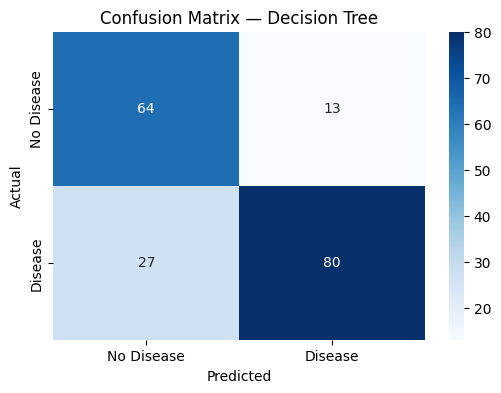

In [24]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix — Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()